# Probability Density Functions

In [1]:
from random import sample
import matplotlib
from matplotlib.lines import lineStyles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f, trimboth, norm
from scipy.integrate import simpson

## Normal distribution PDF

We start with the PDF of the normal distribution. Formula of normal distribution PDF is:

$$
\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Let's evaulate range of weights (NSFG birth data) using Normal PDF.

In [2]:
birth = pd.read_csv("./data/2002FemPreg_after_01.csv")
birth

,caseid,pregordr,howpreg_n,howpreg_p,moscurrp,nowprgdk,pregend1,pregend2,nbrnaliv,multbrth,...,religion_i,metro_i,basewgt,adj_mod_basewgt,finalwgt,secu_p,sest,cmintvw,totalwgt_lb,totalwgt_kg
0,1,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3410.389399,3869.349602,6448.271112,2,9,1231,8.8125,3.997283
1,1,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,3410.389399,3869.349602,6448.271112,2,9,1231,7.8750,3.572040
2,2,1,NaN,NaN,NaN,NaN,5.0,NaN,3.0,5.0,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,9.1250,4.139030
3,2,2,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,7.0000,3.175147
4,2,3,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,7226.301740,8567.549110,12999.542264,2,12,1231,6.1875,2.806603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13588,12571,1,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,6.1875,2.806603
13589,12571,2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,NaN,NaN
13590,12571,3,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,NaN,NaN
13591,12571,4,NaN,NaN,NaN,NaN,6.0,NaN,1.0,NaN,...,0,0,4670.540953,5795.692880,6269.200989,1,78,1227,7.5000,3.401943


In [3]:
trimmed_weight = trimboth(birth["totalwgt_kg"].dropna(), 0.01)

In [4]:
trim_mean, trim_std = np.mean(trimmed_weight), np.std(trimmed_weight)
trim_high, trim_low = trim_mean + trim_std * 4, trim_mean - trim_std * 4

In [5]:
x_ticks = np.linspace(trim_low, trim_high, 201)

In [6]:
norm_dist = norm.pdf(x_ticks, trim_mean, trim_std)
norm_pdf = pd.Series(norm_dist, index=x_ticks)
norm_pdf

1.021660    0.000234
1.044542    0.000274
1.067424    0.000321
1.090306    0.000375
1.113188    0.000438
              ...   
5.506501    0.000438
5.529383    0.000375
5.552265    0.000321
5.575146    0.000274
5.598028    0.000234
Length: 201, dtype: float64

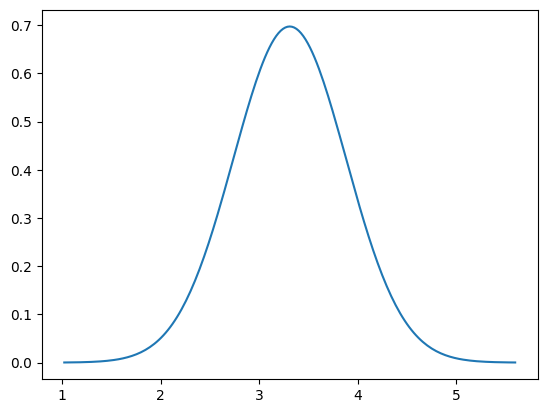

In [7]:
fig, ax = plt.subplots()
ax.plot(norm_pdf.index, norm_pdf)
plt.show()

We know that area under PDF equals to 1, let's test that too.

In [8]:
simpson(x=x_ticks, y=norm_dist)

np.float64(0.999936657318706)

If we wanted to find the fraction of birth weights between 1 and 2 kgs, we could do:

In [9]:
x_between_1_2 = np.linspace(1, 2, 201)
y_between_1_2 = norm.pdf(x_between_1_2, trim_mean, trim_std)
simpson(x=x_between_1_2, y=y_between_1_2)

np.float64(0.01099083812558587)

We can also find the fraction by $F_X(2) - F_X(1)$

In [10]:
norm.cdf(2, trim_mean, trim_std) - norm.cdf(1, trim_mean, trim_std)

np.float64(0.010990838120956284)

## Kernel Density Estimation (KDE)

We can use KDE to estimate a PDF from the discrete data.

In [11]:
birth_weights = birth["totalwgt_kg"].dropna()
trimmed_weight = pd.Series(trimboth(birth_weights, 0.02))

In [12]:
np.random.seed(3)
n = 500
sample_birth_weights = trimmed_weight.sample(n)
sample_birth_weights

450     2.778253
6632    3.827186
5131    3.118448
2005    2.976700
4431    3.288545
          ...   
295     2.097865
5335    3.316894
3344    3.373593
4896    3.231846
455     2.579807
Length: 500, dtype: float64

In [13]:
weight_kde_pmf = pd.Series(1 / n, index=sample_birth_weights)
weight_kde_pmf
len(weight_kde_pmf)

500

We can find the optimal $h$ using _Scott's rule of thumb_.

$$
h \approx 1.06 \cdot \hat{\sigma}n^{\frac{1}{5}}
$$

In [14]:
x_vals = np.linspace(0, 7, 1000)
h = 1.06 * sample_birth_weights.std() * len(sample_birth_weights) ** (-1 / 5)
h

np.float64(0.15986553305845413)

In [15]:
norm_dist = norm.pdf(
    x_vals, loc=sample_birth_weights.mean(), scale=sample_birth_weights.std()
)
norm_pdf = pd.Series(norm_dist, index=x_vals)
norm_pdf

0.000000    9.398033e-10
0.007007    1.023979e-09
0.014014    1.115493e-09
0.021021    1.214967e-09
0.028028    1.323075e-09
                ...     
6.971972    2.783698e-11
6.978979    2.536401e-11
6.985986    2.310658e-11
6.992993    2.104629e-11
7.000000    1.916625e-11
Length: 1000, dtype: float64

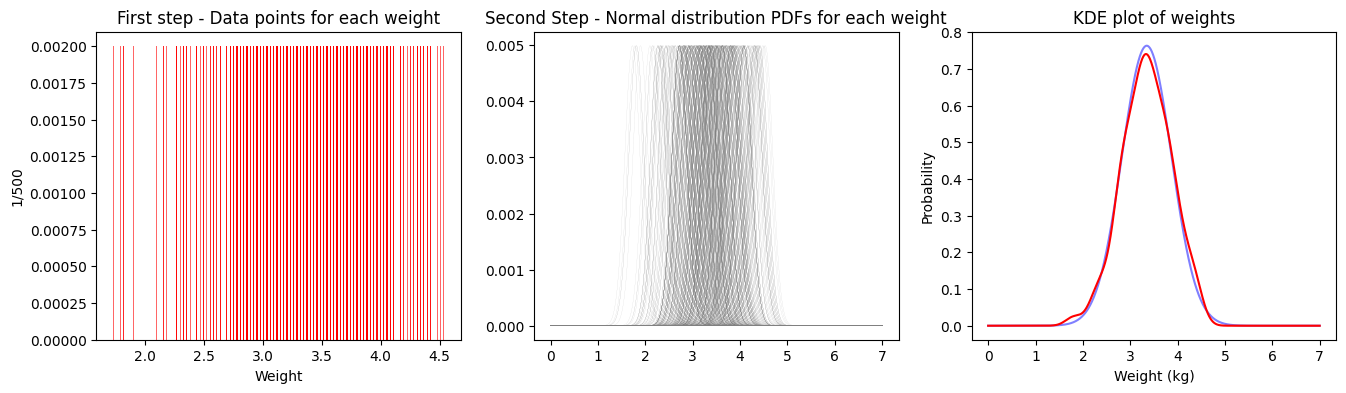

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(weight_kde_pmf.index, weight_kde_pmf, width=0.01, color="red", alpha=0.6)
kde_total = np.zeros_like(x_vals)
for point in sample_birth_weights:
    kernel = norm.pdf(x_vals, loc=point, scale=h) * (1 / n)
    ax[1].plot(x_vals, kernel, color="gray", alpha=0.5, linestyle="-", linewidth=0.1)
    kde_total += kernel

ax[2].plot(norm_pdf.index, norm_pdf, color="blue", alpha=0.5)
ax[2].plot(x_vals, kde_total, color="red")

ax[0].set_xlabel("Weight")
ax[0].set_ylabel(f"1/{n}")
ax[0].set_title("First step - Data points for each weight")

ax[1].set_title("Second Step - Normal distribution PDFs for each weight")

ax[2].set_xlabel("Weight (kg)")
ax[2].set_ylabel("Probability")
ax[2].set_title("KDE plot of weights")


plt.show()

We have our KDE plot. In some cases, like here where we have too many data points, it is better to use KDE plot instead of a histogram.

We can calculate the area below our KDE plot to ensure that our KDE plot is also a PDF.

In [17]:
simpson(x=x_vals, y=kde_total)

np.float64(1.0)

## The Distribution Framework

At this point, we have a complete set of ways to represent distributions: PMFs, CDFs and PDFs. Now, let's learn how to transform one to another.

<img src="/notes/think_stats/assets/distribution_framework.png" height="300"/>